Graph 직접 정의 없이 llm 이 tool 을 직접 선택하고 그래프를 자동으로 생성<br/>
e.g.
```python
from langgraph.prebuilt import create_react_agent
tools = [tavily_search, current_date, counsel, repl_tool]
graph = create_react_agent(llm, tools=tools)
```

## 환경설정 및 Jupyter 설치
### 가상환경 세팅
```bash
conda create --name env-langgraph-fc python=3.10 -y
```
<br/>

### 세팅 확인
가상환경 디렉터리 확인
```bash
ls -al ~/miniforge3/envs/env-langgraph-fc 
```
<br/>

가상환경 활성화
```bash
conda activate env-langgraph-fc
```
<br/>

가상환경을 끌때는 다음과 같이 한다.
```bash
conda deactivate
```
<br/>

### 의존성 설정
먼저 jupyter 설치
```bash
# pip 대신 mamba를 사용하면 패키지 설치 속도가 훨씬 빠릅니다.
mamba install -c conda-forge jupyter notebook ipykernel -y
```
<br/>

다음 의존성 설치
```bash
## pip 를 이용해 설치
!pip install langgraph langchain langchain_google_genai langchain_community

## 또는 mamba 를 이용해 설치
mamba install langgraph langchain langchain_google_genai langchain_community
```
<br/>

keyring 라이브러리 설치
```bash
## pip 을 이용해 설치
pip install keyring

## 또는 mamba 를 이용해 keyring 설치
mamba install keyring
```
<br/>

## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [1]:
import keyring
gemini_service_name = "gemini-api-key---alpha300uk"
gemini_username = "alpha300uk"
gemini_api_token = keyring.get_password(gemini_service_name, gemini_username)

tavily_service_name = "tavily-api-key---alpha300uk"
tavily_username = "alpha300uk"
taviliy_api_token = keyring.get_password(tavily_service_name, tavily_username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [2]:
! pip install langgraph langchain langchain_google_genai langchain_community langchain_tavily langchain_experimental

## llm, ratelimiter 선언

In [5]:
## llm, ratelimiter 선언
import os
os.environ['GOOGLE_API_KEY'] = gemini_api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

## Tool 정의 및 예제

2026-03-27
네!
=== 테스트 시작 ===
4

=== 이 메시지가 보여야 합니다 ===


/var/folders/9p/67xd5xr944l81sth4p9pb4r40000gn/T/ipykernel_87021/4168749291.py:89: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(llm, tools=tools)


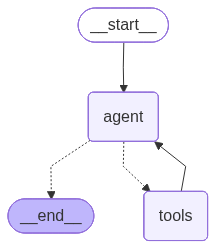

In [6]:
# Tavily API
os.environ['TAVILY_API_KEY'] = taviliy_api_token


from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import random

tavily_search = TavilySearch(
    max_results=5)

@tool
def current_date() -> str:
    "현재 날짜를 %y-%m-%d 형식으로 반환합니다."
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d")


@tool
def counsel(problem:str) -> str: # 나중에는 LLM 기반의 모듈이나, 개별 에이전트로 처리 가능
    "고민에 대한 답을 예/아니오로 얻습니다."
    if random.random()>=0.5:
        return '네!'
    else:
        return '아니오.'

print(current_date.invoke({}))
print(counsel.invoke({'problem':'아무 고민'}))


## 전 시간에 이어 새로운 tool 추가 (python repl)
from langchain_core.tools import tool
from io import StringIO
import sys
from contextlib import redirect_stdout

def python_repl(code: str) -> str:
    """
    Python 코드를 실행합니다.
    결과를 보려면 반드시 print()를 사용하세요.
    
    Args:
        code: 실행할 Python 코드
    
    Returns:
        실행 결과
    """
    # 코드 정리
    code = code.strip().strip('`')
    if code.startswith('python'):
        code = code[6:].strip()
    
    # stdout 캡처 (context manager 사용으로 안전하게)
    buffer = StringIO()
    
    try:
        # redirect_stdout을 사용하면 자동으로 복원됨
        with redirect_stdout(buffer):
            exec(code, globals())
        
        # 결과 가져오기
        output = buffer.getvalue()
        return output if output else "실행 완료 (출력 없음)"
        
    except Exception as e:
        return f"Error: {type(e).__name__}: {str(e)}"

@tool
def repl_tool(code: str) -> str:
    """
    파일 시스템 처리, 외부 API 호출 등의 다양한 작업을 위해
    Python 코드를 실행합니다.
    결과를 보려면 반드시 print()를 사용하세요.
    """
    result = python_repl(code)
    return result

# 테스트
print("=== 테스트 시작 ===")
print(python_repl("print(2 + 2)"))
print("=== 이 메시지가 보여야 합니다 ===")

### 
## react agent 그래프 생성
from langgraph.prebuilt import create_react_agent

tools = [tavily_search, current_date, counsel, repl_tool]

graph = create_react_agent(llm, tools=tools)


# LangChain V1에서는 아래 코드로 변경
# from langchain.agents import create_agent
# agent = create_agent(llm, tools=tools, system_prompt = prompt)

graph

#### Q
이 코드는 우리가 graph 를 정의하는 대신 langgraph.prebuilt 내의 create_react_agent 를 이용해서 tool 을 선택하도록 그래프를 작성한 코드인가요?<br/>

Answer<br/>
네, 정확하게 짚으셨습니다! 이 코드는 **우리가 수동으로 노드와 엣지를 연결하던 복잡한 과정을 `create_react_agent`라는 미리 구현된(Prebuilt) 도구로 한 번에 처리**한 것입니다.

이 함수의 주요 특징은 다음과 같습니다:

1.  **ReAct 패턴 자동화**: 
    *   질문을 받고(`Reasoning`) -> 도구를 호출하고(`Acting`) -> 결과를 보고 다시 판단하는 순환 구조를 자동으로 만들어 줍니다.
    *   이전 시간에 실습했던 `StateGraph` 정의, 노드 추가(`add_node`), 엣지 연결(`add_edge`), 조건부 분기(`add_conditional_edges`) 과정을 내부적으로 알아서 수행합니다.

2.  **간결함**: 
    *   우리가 직접 `tools_condition`을 작성하거나 `MessagesState`를 정의할 필요 없이, `llm`과 `tools` 목록만 넘겨주면 즉시 실행 가능한 그래프가 생성됩니다.

3.  **내부 구조**:
    *   이 함수가 만든 그래프를 시각화해보면, 우리가 이전 실습에서 직접 만들었던 **`LLM 노드 <-> Tool 노드` 사이를 반복해서 도는 구조**와 거의 동일하게 구성되어 있습니다.

**요약하자면:** 
"지난번에는 자동차의 부품을 하나하나 조립(StateGraph)했다면, 이번에는 **완성된 자동변속기 차량(`create_react_agent`)**을 가져와서 바로 운전하기 시작한 것"이라고 이해하시면 됩니다.


#### 💡 `create_react_agent`를 통한 에이전트 생성

이번 실습에서는 `StateGraph`를 사용해 노드와 엣지를 직접 연결하는 대신, **LangGraph의 Prebuilt 도구인 `create_react_agent`**를 사용했습니다.

- **주요 특징**:
    - **자동 그래프 구성**: `LLM 노드 <-> Tools 노드` 간의 순환 구조(ReAct 패턴)를 내부적으로 자동으로 생성합니다.
    - **워크플로우 간소화**: `State` 정의, `add_node`, `add_edge`, `tools_condition` 등의 수동 설정 과정을 생략할 수 있습니다.
    - **고수준 API**: 개발자는 `llm`과 `tools` 목록만 전달하면 즉시 실행 가능한 에이전트를 얻을 수 있습니다.

- **비교**:
    - **이전 실습**: 부품(노드, 엣지)을 하나씩 조립하여 자동차(그래프)를 만듦
    - **이번 실습**: 완성차(`create_react_agent`)를 가져와서 바로 운전함

테스트

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

for data in graph.stream(
    {'messages':[
        HumanMessage(content='''
오늘 날짜 확인해서 txt 파일로 저장해, 파일 이름은 날짜.txt로 해.''')]},
    stream_mode='updates'):
    print(data)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'current_date', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'0891b2c3-777e-4a43-8ccb-1d80646b354a': 'Ct4FAb4+9vtdnl+VX8+IKo68g4oYB6Id9apDikerYF4vmdwdtt7xMNN8TZ8DhxDCc77fLiLHrOtMqF8at+jOh3iEZbqmaoba+nmdi8Z43KGg1p8js3qH5mBtYZH/SgTuKJTDbcE4HPlHJbYV13HWq6+chrJet80jvCzAaD709lUXT6uaxhZnGQOP5Cte+2wkDf/GXKyUe+EUWW6USF9rL0NOllrkJl/eer1qL0OG6TVRWgW9DPoBsP2Pgu6y9jaS1CEOyVYElJMhxtdJ1QRIbZnFD+fV2czSb0NaBlg7oQ60VqyrlVK8UqkinX+33CsNn3Ra1Sy2gYwKc32hoESAdlffs66ccd6Z0lYo4ds7d4niFOBMI55cnrfy/76yrIH93X1vaW2CHKuLwS1jwt1oj8JFCgSCAvle250fv4K0M+HmJhXIys1QJ6TGInq8+5t8U0S7LwwTLmGV6IrXY6fNvKZ6wP7D5YNbDFfvO/gTdJWJAQ5842oIQkYUYhNvXjR8Qirc0C379YbYHB2ty0gRjwyag6nkMs3h34+xvi8b4jX7P9SB6Lxw6r0vOtAswloTXEPtC+RQwrRuWxXjsdCG51b/R46jQdJHOm07qio/0nkQJND07rTuPnKVLGTC5K5XJkWV5ZjkgBL1+xScyWmY14wHd0WF7wmoC4ph2At+2jOE+Hs9mbUrFj3GjDYaOYbjumdgc0XU0/G3cp8Vm5pS9OzY1zrDRzIUMs3sy03p5OWoVFY0/IC3DwPFqUAZEhMmPUKt+k5ShqjaYUxF

## 이번에는 tool node, tool condition 없이 Prebuilt 없이 구현

2026-03-27
아니오.
=== 테스트 시작 ===
4

=== 이 메시지가 보여야 합니다 ===


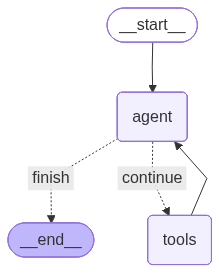

In [9]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import random

tavily_search = TavilySearch(
    max_results=5)

@tool
def current_date() -> str:
    "현재 날짜를 %y-%m-%d 형식으로 반환합니다."
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d")


@tool
def counsel(problem:str) -> str: # 나중에는 LLM 기반의 모듈이나, 개별 에이전트로 처리 가능
    "고민에 대한 답을 예/아니오로 얻습니다."
    if random.random()>=0.5:
        return '네!'
    else:
        return '아니오.'

print(current_date.invoke({}))
print(counsel.invoke({'problem':'아무 고민'}))


## 전 시간에 이어 새로운 tool 추가 (python repl)
from langchain_core.tools import tool
from io import StringIO
import sys
from contextlib import redirect_stdout

def python_repl(code: str) -> str:
    """
    Python 코드를 실행합니다.
    결과를 보려면 반드시 print()를 사용하세요.
    
    Args:
        code: 실행할 Python 코드
    
    Returns:
        실행 결과
    """
    # 코드 정리
    code = code.strip().strip('`')
    if code.startswith('python'):
        code = code[6:].strip()
    
    # stdout 캡처 (context manager 사용으로 안전하게)
    buffer = StringIO()
    
    try:
        # redirect_stdout을 사용하면 자동으로 복원됨
        with redirect_stdout(buffer):
            exec(code, globals())
        
        # 결과 가져오기
        output = buffer.getvalue()
        return output if output else "실행 완료 (출력 없음)"
        
    except Exception as e:
        return f"Error: {type(e).__name__}: {str(e)}"

@tool
def repl_tool(code: str) -> str:
    """
    파일 시스템 처리, 외부 API 호출 등의 다양한 작업을 위해
    Python 코드를 실행합니다.
    결과를 보려면 반드시 print()를 사용하세요.
    """
    result = python_repl(code)
    return result

# 테스트
print("=== 테스트 시작 ===")
print(python_repl("print(2 + 2)"))
print("=== 이 메시지가 보여야 합니다 ===")


from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages : Annotated[list, add_messages]   # 메시지 맥락을 저장하는 리스트

## tools 는 위에서 정의함
### tools = [tavily_search, current_date, counsel, repl_tool]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools




from langchain_core.messages import ToolMessage

tool_list = {tool.name: tool for tool in tools}
# tool 목록 dict로 생성

def tool_node(state):
    tool_outputs = []
    tool_call_msgs = state['messages'][-1]
    # 마지막 메시지: 툴 콜링 메시지

    for tool_call in tool_call_msgs.tool_calls:
    # 여러 개의 툴 콜이 필요한 경우를 고려해 for로 표시
        tool_exec = tool_list[tool_call['name']]
        # 실제 함수 찾기
        tool_result = tool_exec.invoke(tool_call)
        # tool 실행 결과 얻기 (결과는 ToolMessage 타입: 1번 실습 참고)
        tool_outputs.append(tool_result)

    return {'messages': tool_outputs}

def agent(state):

    # system_prompt = SystemMessage("주어진 툴을 사용하여, 사용자의 질문에 답하세요.")

    # ReAct 목적에 충실한 버전
    system_prompt = SystemMessage("""주어진 툴을 사용하여, 사용자의 질문에 답하세요.
툴을 실행하기 전, 직전까지의 결과의 의미를 파악하고 맥락에 맞게 다음 툴을 실행하기 위한 Planning Step을 메시지에 포함해 출력하세요.
파일 시스템 접근은 파이썬 코드를 실행하여 처리하세요.
에러가 발생하면, 전략을 바꿔 다시 실행하세요.""")


    response = llm_with_tools.invoke([system_prompt] + state["messages"])
    # Tool Calling이 필요한 경우와 필요하지 않은 경우를 구분할할 필요
    return {'messages': response}

def tool_needed(state):

    last_msg = state['messages'][-1]
    if last_msg.tool_calls: # 툴 콜링이 필요하면
        return "continue"
    else:
        return "finish"


from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("agent", agent)
builder.add_node("tools", tool_node)

builder.add_edge(START, 'agent'),
builder.add_conditional_edges("agent",
                              tool_needed,
                               {"continue": "tools","finish": END})
builder.add_edge("tools", "agent")

graph = builder.compile()
graph

이 코드는 **사용자가 `StateGraph`를 사용하여 노드(Node), 엣지(Edge), 상태(State) 및 조건부 로직을 직접 하나하나 정의한 코드**입니다.

이전의 `create_react_agent`(고수준 API)와 비교했을 때, 이 방식(저수준 API)의 특징은 다음과 같습니다:

1.  **상태(State) 정의**: `class State(TypedDict):`를 통해 그래프가 유지할 데이터 구조를 직접 결정했습니다.
2.  **노드 함수 직접 구현**:
    *   `agent(state)`: LLM이 어떻게 행동할지(시스템 프롬프트 포함) 정의했습니다.
    *   `tool_node(state)`: 도구를 실제로 어떻게 실행하고 결과를 메시지로 반환할지 직접 코딩했습니다.
3.  **흐름 제어(Conditional Edge)**: `tool_needed` 함수를 만들어, 다음 단계가 `tools`로 갈지 `END`로 갈지 결정하는 로직을 직접 구현했습니다.
4.  **그래프 조립**: `builder.add_node`, `builder.add_edge` 등을 사용하여 워크플로우를 수동으로 설계했습니다.

**이 방식의 장점:**
*   **커스터마이징**: `agent` 함수 안에 복잡한 시스템 프롬프트(Planning Step 포함 등)를 넣거나, 툴 실행 로직을 입맛대로 수정할 수 있습니다.
*   **세밀한 제어**: 에이전트의 사고 과정이나 도구 사용 방식에 대해 훨씬 더 깊은 수준의 제어가 가능합니다.

**요약하자면:** 
앞의 코드가 '완성된 기성복(`create_react_agent`)'이었다면, 이 코드는 **'원단 선택부터 바느질까지 직접 한 맞춤복(`StateGraph` 수동 정의)'**이라고 할 수 있습니다.

In [10]:
response = graph.invoke({'messages':[HumanMessage(content="패스트캠퍼스 랭그래프 과정 검색해서 소개해줘.")]})
response

{'messages': [HumanMessage(content='패스트캠퍼스 랭그래프 과정 검색해서 소개해줘.', additional_kwargs={}, response_metadata={}, id='4d900a9c-9db0-425c-b823-131e47bd71b1'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"search_depth": "basic", "query": "\\ud328\\uc2a4\\ud2b8\\ucea0\\ud37c\\uc2a4 \\ub7ad\\uadf8\\ub798\\ud504 \\uacfc\\uc815"}'}, '__gemini_function_call_thought_signatures__': {'8b96eeb8-3e6e-49d4-a454-baa49fd26736': 'CokCAb4+9vuzGqD2gGTN/ApzzJyBVC+FRtQD2RS8Ft+veB2qybkipPJ0qhUAFsLEC61EriYLuWLiPVgeQ5WzntIgh0E0O7e0k9AI2ABoeUF8wnS6BG25+paRz5xGjBCLamNaS7fCzjOpR61Ytl3+pVVX58dOgbN9E/QOpbt9NV71t8M7CftSh3q7/6UMoZH70Xr7lMw/xG+Yz3B5iz/u9vOK0MX23PQHmcRKR2m8/eLf80zpu33ypGen/fdTK6EQIQkLBq7BLfbnKNvRnbpwv6mNjD5udqErkPy2Vq8cV+SiLMauChw8eUSrIHh04dovR88xDtMSl5tnGs5EKT+UgGQpO/qAHnIZ3dSGdA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2cdd-2b49

In [11]:
for data in graph.stream(
    {'messages':[HumanMessage(content='''
    오늘 날짜 확인해서 txt 파일로 저장해, 파일 이름은 날짜.txt로 해.''')]}, stream_mode='updates'):
    print(data)
    print('----------')

{'agent': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'current_date', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'93022a2a-ad2b-48bd-ae64-39f817d2557c': 'CrsDAb4+9vtNynBvDGo2on9anfzgmEF5PRNWL+ZSsmwEwNjrrTQs3FV3DsBAuJX/ED5dtWKiEw6stcptLTzdXngKA3TrRrcBpc7GUtZXu8/SKHVxQ37cu/Nn41dqFbm3SYxa7Tg6T/j1druy7y89dwT1/xvDpfgGd/79sXwNJeWFRz+1tKbqR/MtjMwHcsRKg8RIWN0Of83Z+byBeVa0BifWkLcAhaF9lsPjXcw9lwEiNOBtShgCLuC13ViAURXLOaZ4+W8tVLVTCZ+kX+OS7vAyVdNqJtutK6F7ZNnq7l8n/lyqFJ3yCsvP99cuUPDgAujUEJ0O5ENCKLZpEGwXU/LVq/32FVam+l82Kc113dq02JcAPEpw58GzTm9+6du6kSCqRkAEoqKNDLiPsOMoqn1ie4KglBUz713Zzzx7kv/wMom2yAfqHxG0CqcVfCBw12DxPo5z5e/rlnKj9jyylgHDhcp2TxH63bR9UMzVhC4XPtVo90h+BxyNPxb7kZYvuMqryOatvdivxF9n4M/KU4to85NsBTnrB7jFxXDbRev4GkiJbTmFeEnQvRKR4DqF9ZwG6svSa4M9p7jJFBU='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2cdd-a963-7000-9928-5d1caee